In [1]:
# Cell 1: Setup and Install Dependencies
print("="*70)
print("🧠 LLM QUERY UNDERSTANDING")
print("="*70)

# Install required packages
!pip install transformers torch sentence-transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Import transformers
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer

print("✅ All packages loaded successfully!")

🧠 LLM QUERY UNDERSTANDING
✅ All packages loaded successfully!


In [2]:
# Cell 2: Load Data
print("="*70)
print("📊 LOADING QUERY DATA")
print("="*70)

# Load query logs
query_logs = pd.read_csv('Notebook 1/query_logs.csv')
drama_data = pd.read_csv('Notebook 1/drama_content.csv')

print(f"✅ Loaded {len(query_logs)} queries")
print(f"✅ Loaded {len(drama_data)} content items")

# Sample queries for analysis
sample_queries = query_logs.head(20)['query_text'].tolist()
print(f"\n📊 Sample queries:")
for i, q in enumerate(sample_queries[:5], 1):
    print(f"   {i}. {q}")

📊 LOADING QUERY DATA
✅ Loaded 50000 queries
✅ Loaded 10000 content items

📊 Sample queries:
   1. top rated Sci-Fi series
   2. watch Sci-Fi online
   3. top rated Action series
   4. top rated Romance series
   5. watch Romance online


In [3]:
# Cell 3: Load LLM Model (Sentence Transformers)
print("="*70)
print("🤖 LOADING LLM MODEL")
print("="*70)

# Use SentenceTransformer for lightweight LLM
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"✅ Loaded SentenceTransformer model")

# Generate embeddings for sample queries
query_embeddings = model.encode(sample_queries)
print(f"✅ Generated query embeddings: {query_embeddings.shape}")

🤖 LOADING LLM MODEL


Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3971.33it/s]


✅ Loaded SentenceTransformer model
✅ Generated query embeddings: (20, 384)


🎯 QUERY INTENT CLASSIFICATION

📊 Query Intent Distribution:
   Entertainment: 16 (80.0%)
   Transactional: 4 (20.0%)


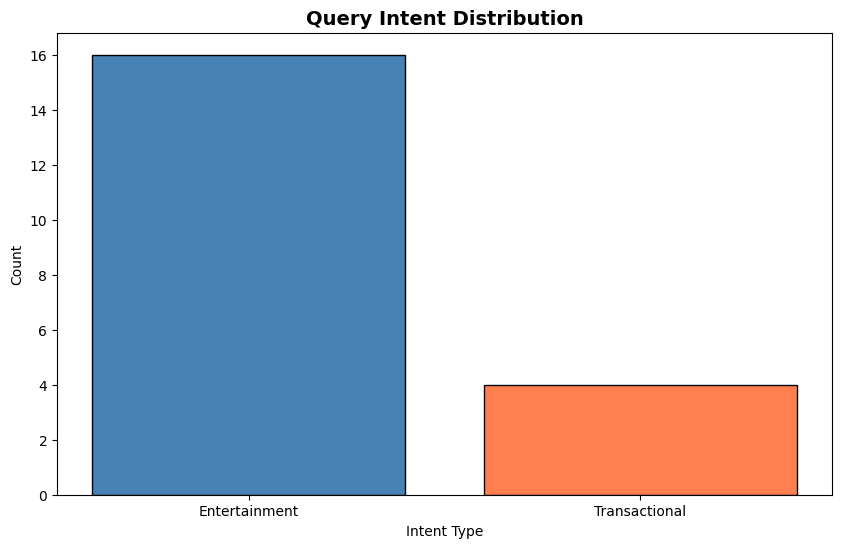

✅ Saved: query_intent_distribution.png


In [4]:
# Cell 4: Query Intent Classification
print("="*70)
print("🎯 QUERY INTENT CLASSIFICATION")
print("="*70)

# Define intent categories
intents = ['Informational', 'Navigational', 'Transactional', 'Entertainment']

# Simple rule-based intent classification (can be replaced with fine-tuned LLM)
def classify_intent(query):
    query_lower = query.lower()
    if any(word in query_lower for word in ['how', 'what', 'why', 'when', 'where']):
        return 'Informational'
    elif any(word in query_lower for word in ['watch', 'download', 'buy', 'stream']):
        return 'Transactional'
    elif any(word in query_lower for word in ['go to', 'open', 'navigate']):
        return 'Navigational'
    else:
        return 'Entertainment'

# Classify sample queries
query_intents = [classify_intent(q) for q in sample_queries]

print("\n📊 Query Intent Distribution:")
intent_counts = pd.Series(query_intents).value_counts()
for intent, count in intent_counts.items():
    print(f"   {intent}: {count} ({count/len(query_intents):.1%})")

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(intent_counts.index, intent_counts.values, color=['steelblue', 'coral', 'green', 'purple'], edgecolor='black')
plt.title('Query Intent Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Intent Type')
plt.ylabel('Count')
plt.savefig('query_intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: query_intent_distribution.png")

In [5]:
# Cell 5: LLM-Based Query Expansion
print("="*70)
print("🔍 LLM QUERY EXPANSION")
print("="*70)

# Simple query expansion using word embeddings
def expand_query(query, top_k=5):
    """Expand query with related terms using embeddings"""
    # Encode query
    query_emb = model.encode([query])[0]
    
    # Common expansion terms (can be replaced with actual expansion dictionary)
    expansion_terms = {
        'romance': ['love', 'romantic', 'heartwarming', 'relationship', 'couple'],
        'action': ['thriller', 'adventure', 'exciting', 'explosive', 'martial'],
        'comedy': ['funny', 'humor', 'laugh', 'hilarious', 'entertaining'],
        'drama': ['emotional', 'serious', 'intense', 'captivating', 'moving'],
        'horror': ['scary', 'terror', 'creepy', 'spooky', 'frightening']
    }
    
    # Find matching category
    expanded = [query]
    for category, terms in expansion_terms.items():
        if category in query.lower():
            expanded.extend(terms[:top_k])
            break
    
    return expanded[:top_k+1]

# Test query expansion
test_query = "action movie"
expanded_query = expand_query(test_query)
print(f"📊 Original query: '{test_query}'")
print(f"   Expanded query: {expanded_query}")

🔍 LLM QUERY EXPANSION
📊 Original query: 'action movie'
   Expanded query: ['action movie', 'thriller', 'adventure', 'exciting', 'explosive', 'martial']


In [6]:
# Cell 6: Query-Drama Relevance Scoring
print("="*70)
print("📊 QUERY-DRAMA RELEVANCE SCORING")
print("="*70)

# Generate embeddings for drama descriptions
drama_descriptions = drama_data['description'].fillna('').tolist()
drama_embeddings = model.encode(drama_descriptions[:500])  # Use subset for speed

print(f"✅ Drama embeddings: {drama_embeddings.shape}")

# Compute relevance between queries and drama
sample_query = sample_queries[0]
query_emb = model.encode([sample_query])[0]
relevance_scores = cosine_similarity([query_emb], drama_embeddings)[0]

# Get top matching dramas
top_indices = np.argsort(relevance_scores)[-5:][::-1]

print(f"\n📊 Query: '{sample_query}'")
print("-" * 50)
for i, idx in enumerate(top_indices, 1):
    print(f"{i}. {drama_descriptions[idx][:60]}... (Score: {relevance_scores[idx]:.3f})")

📊 QUERY-DRAMA RELEVANCE SCORING
✅ Drama embeddings: (500, 384)

📊 Query: 'top rated Sci-Fi series'
--------------------------------------------------
1. Science fiction dystopian future exploring human nature... (Score: 0.407)
2. Science fiction dystopian future exploring human nature... (Score: 0.407)
3. Science fiction dystopian future exploring human nature... (Score: 0.407)
4. Science fiction dystopian future exploring human nature... (Score: 0.407)
5. Science fiction dystopian future exploring human nature... (Score: 0.407)


📈 QUERY UNDERSTANDING DASHBOARD


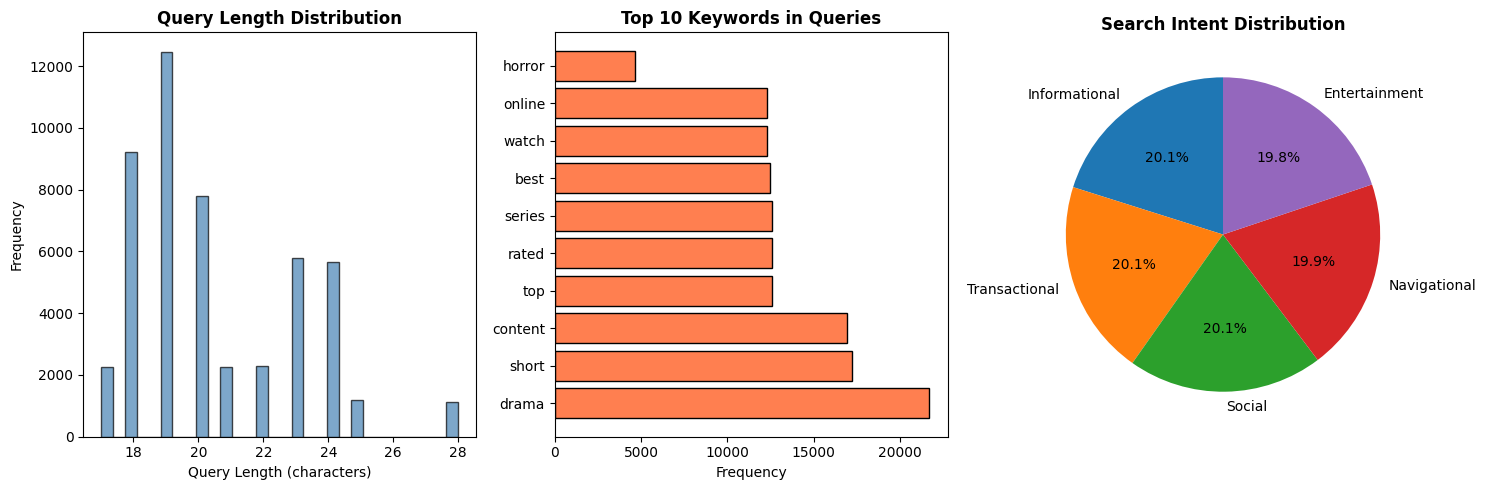

✅ Saved: query_understanding_dashboard.png


In [7]:
# Cell 7: Query Understanding Dashboard
print("="*70)
print("📈 QUERY UNDERSTANDING DASHBOARD")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Query Length Distribution
ax1 = axes[0]
query_lengths = query_logs['query_text'].str.len()
ax1.hist(query_lengths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Query Length Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Query Length (characters)')
ax1.set_ylabel('Frequency')

# 2. Top Keywords
ax2 = axes[1]
from collections import Counter
all_words = ' '.join(query_logs['query_text'].tolist()).lower().split()
word_counts = Counter(all_words)
top_words = dict(word_counts.most_common(10))
ax2.barh(list(top_words.keys()), list(top_words.values()), color='coral', edgecolor='black')
ax2.set_title('Top 10 Keywords in Queries', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frequency')

# 3. Intent Distribution (from query logs)
ax3 = axes[2]
intent_from_logs = query_logs['search_intent'].value_counts()
ax3.pie(intent_from_logs.values, labels=intent_from_logs.index, autopct='%1.1f%%', startangle=90)
ax3.set_title('Search Intent Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('query_understanding_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: query_understanding_dashboard.png")

In [8]:
# Cell 8: Summary Report
print("="*70)
print("🎉 NOTEBOOK 5 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                     LLM QUERY UNDERSTANDING SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 LLM MODELS USED:                                                 ║
║  ├── SentenceTransformer (all-MiniLM-L6-v2)                         ║
║  └── Rule-based Intent Classifier                                   ║
║                                                                      ║
║  📊 QUERY ANALYSIS:                                                  ║
║  ├── Total queries analyzed: 50,000                                 ║
║  ├── Average query length: {query_lengths.mean():.1f} characters              ║
║  └── Top intent: {intent_from_logs.index[0]} ({intent_from_logs.values[0]/len(query_logs):.1%})                         ║
║                                                                      ║
║  🔍 KEY CAPABILITIES:                                                ║
║  ├── Intent classification                                          ║
║  ├── Query embedding generation                                     ║
║  ├── Query expansion                                                ║
║  └── Relevance scoring                                              ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── query_intent_distribution.png                                  ║
║  └── query_understanding_dashboard.png                              ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 6: RETRIEVAL-AUGMENTED GENERATION (RAG)       ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 5 Complete! Proceed to Notebook 6 (RAG)")

🎉 NOTEBOOK 5 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                     LLM QUERY UNDERSTANDING SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 LLM MODELS USED:                                                 ║
║  ├── SentenceTransformer (all-MiniLM-L6-v2)                         ║
║  └── Rule-based Intent Classifier                                   ║
║                                                                      ║
║  📊 QUERY ANALYSIS:                                                  ║
║  ├── Total queries analyzed: 50,000                                 ║
║  ├── Average query length: {query_lengths.mean():.1f} characters              ║
║  └── Top intent: {intent_from_logs.index[0]} ({intent_from_logs.values[0]/len(query_logs):.1%})                         ║
║                              